<a href="https://www.kaggle.com/code/arpit786/mnist-pytorch-ann-gpu-optimized?scriptVersionId=322054562" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ebertolo/mnist-csv/train.csv


In [2]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device {device}")
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

Using device cuda
2
Tesla T4


In [4]:
# Set random seeds for reproducibility
torch.manual_seed(45)

In [5]:
df = pd.read_csv('/kaggle/input/datasets/ebertolo/mnist-csv/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


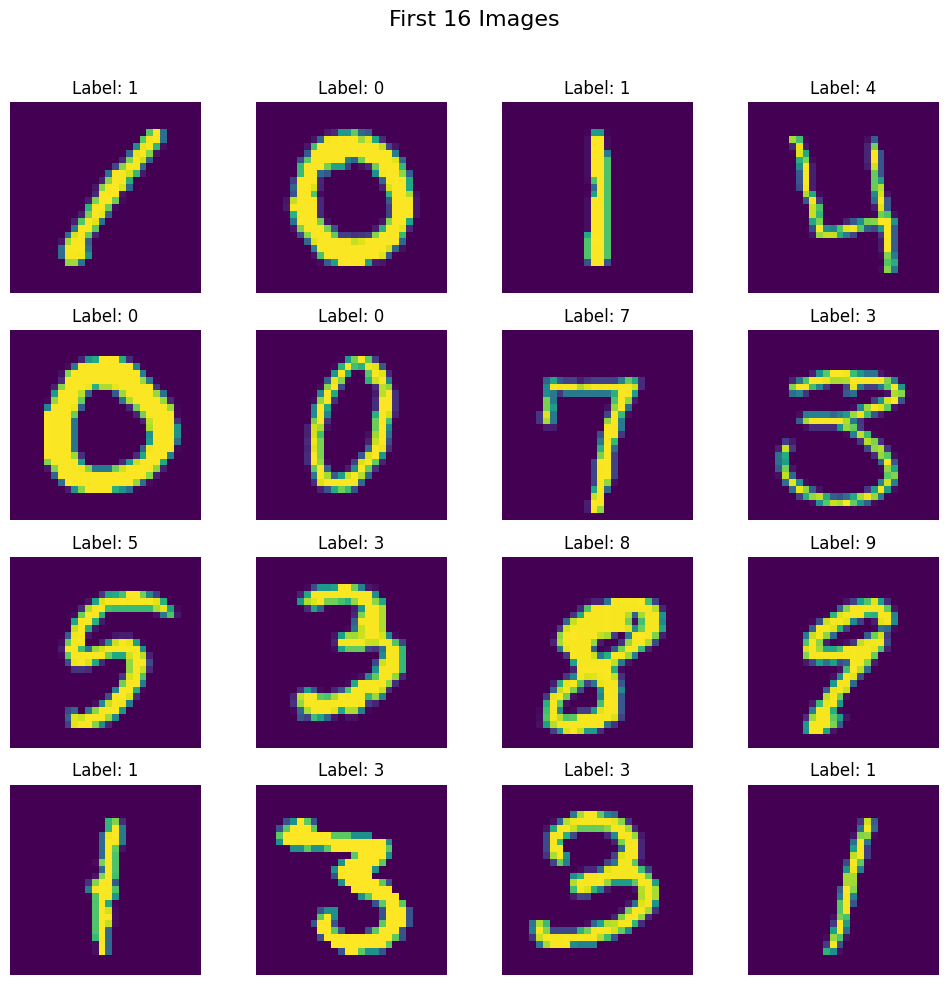

In [6]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [7]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train.shape

(33600, 784)

In [10]:
# scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

In [11]:
X_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.24705882, 0.99215686,
       0.4745098 , 0.        , 0.        , 0.        , 0.     

In [12]:
# Create Custom Dataset class (Abstract class of Dataset)
class CustomDataset(Dataset):

    def __init__(self,features,labels):
        self.features = torch.tensor(features,dtype=torch.float32)
        
        self.labels = torch.tensor(labels,dtype=torch.long)

    def __len__(self):

        return len(self.features)

    def __getitem__(self,index):

        return self.features[index],self.labels[index]

In [13]:
# Create train_dataset object
train_dataset = CustomDataset(X_train,y_train)

In [14]:
# Feature and label
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2471, 0.9922, 0.4745, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2471, 0.9961, 0.7922,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [15]:
# Create test_dataset object
test_dataset = CustomDataset(X_test,y_test)

In [16]:
# Setting learning rate and epochs
class MyNN(nn.Module):

    def __init__(self,num_features):

        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.BatchNorm1d(128),# batch Normalisation
            nn.ReLU(),
            nn.Dropout(p=0.4), # Dropping Nodes
            nn.Linear(128,64),
            nn.BatchNorm1d(64),# batch Normalisation
            nn.ReLU(),
            nn.Dropout(p=0.3), # Dropping Nodes
            nn.Linear(64,10)
        )
# nn.CrossEntropyLoss() already applies Softmax internally.
# That is why in PyTorch we should NOT add a separate Softmax layer at the end of your model.
    def forward(self,x):
        return self.model(x)

In [17]:
# Set learning rate and epochs
epochs =70
learning_rate = 0.1

In [18]:
# Instantiate the model
model = MyNN(X_train.shape[1])
model = model.to(device)
# Loss Function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(model.parameters(),lr= learning_rate,weight_decay=1e-4)

In [19]:
# Create train and test loader
train_loader = DataLoader(train_dataset,batch_size=128,shuffle=True,pin_memory=True)
test_loader = DataLoader(test_dataset,batch_size=128,shuffle=False,pin_memory=True)

In [20]:
len(train_loader)

263

In [21]:
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features,batch_labels in train_loader:

        # Mode data to GPU
        batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)
        
        # Forward pass
        outputs = model(batch_features)

        # Calculate loss
        loss = criterion(outputs,batch_labels)

        # Backpass
        optimizer.zero_grad()
        loss.backward()

        # update grads
        optimizer.step()
        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    print(f'Epoch: {epoch+1},Loss:{avg_loss}')

Epoch: 1,Loss:0.5936310540587276
Epoch: 2,Loss:0.3239379688927429
Epoch: 3,Loss:0.2683697913989368
Epoch: 4,Loss:0.24139462898665962
Epoch: 5,Loss:0.21675627525655036
Epoch: 6,Loss:0.20635267993003242
Epoch: 7,Loss:0.1892389226492367
Epoch: 8,Loss:0.18035022659446803
Epoch: 9,Loss:0.16878300939222707
Epoch: 10,Loss:0.16359072797595323
Epoch: 11,Loss:0.15486982993129994
Epoch: 12,Loss:0.14915408211062617
Epoch: 13,Loss:0.14330752699604052
Epoch: 14,Loss:0.13227021641774322
Epoch: 15,Loss:0.13471886923557905
Epoch: 16,Loss:0.1266531858154123
Epoch: 17,Loss:0.12335973605513573
Epoch: 18,Loss:0.11907202078334052
Epoch: 19,Loss:0.12155495938834356
Epoch: 20,Loss:0.10773756728992716
Epoch: 21,Loss:0.1107892768861223
Epoch: 22,Loss:0.11243237206577801
Epoch: 23,Loss:0.10429333255204865
Epoch: 24,Loss:0.10638289611092538
Epoch: 25,Loss:0.10333063765057139
Epoch: 26,Loss:0.09955499687377264
Epoch: 27,Loss:0.09670150708477987
Epoch: 28,Loss:0.09700497873694044
Epoch: 29,Loss:0.09538448416404852


In [22]:
# Evaluation mode --> Tells everyone to stop updating weights, all droputs will come alive

model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [23]:
len(test_loader)

66

In [24]:
# Evaluation code
total = 0
correct = 0

with torch.no_grad():
    for batch_features,batch_labels in test_loader:
        
        # Mode data to GPU
        batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)
        
        outputs = model(batch_features)
        
        # Coloumn wise max value index
        _,predicted = torch.max(outputs,1)
        total = total +batch_labels.shape[0]
        correct = correct + (predicted==batch_labels).sum().item()

print(correct/total)

0.9771428571428571


In [26]:
# Evaluation code
total = 0
correct = 0
model.train()

with torch.no_grad():
    for batch_features,batch_labels in train_loader:
        
        # Mode data to GPU
        batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)
        
        outputs = model(batch_features)
        
        # Coloumn wise max value index
        _,predicted = torch.max(outputs,1)
        total = total +batch_labels.shape[0]
        correct = correct + (predicted==batch_labels).sum().item()

print(correct/total)

0.9811011904761905
